# LLMP Inspector — Food CPI Single-Inference Playground

This notebook is a **read-the-LLM's-mind** tool.  It lets you configure a
single inference through the `ContinuousLLMPredictor` (LLMP) for any food CPI
task and origin date, and shows you **exactly**:

1. The history data that will be serialised into the prompt.
2. The exact system prompt and user prompt sent to the LLM.
3. The raw JSON string returned by the model.
4. The parsed numerical trajectories and the resulting quantile forecasts.

**Nothing here is a backtest.**  This notebook is for understanding, debugging,
and iterating on the model's behaviour — not for producing evaluation results.

Prerequisites:
```bash
uv run python scripts/fetch_cpi.py   # populate StatCan cache
# set GEMINI_API_KEY (or your chosen provider key) in .env
```

---
## 1. Setup

In [1]:
from __future__ import annotations

import json
import textwrap
import warnings
from pathlib import Path

import litellm
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import MultiTargetBacktestSpec, describe_spec
from aieng.forecasting.methods import ContinuousLLMPredictor, ContinuousLLMPredictorConfig
from aieng.forecasting.methods.llm_processes.base import get_history_and_meta, serialize_history
from aieng.forecasting.methods.llm_processes.continuous import (
    _build_system_prompt,
    _build_user_prompt,
    _TRAJECTORY_JSON_SCHEMA,
)
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service

STATCAN_CACHE = ROOT / "data" / "statcan"
SPECS_DIR = ROOT / "reference_specs" / "food_cpi"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Data service ready — {len(CATEGORY_LABELS)} food CPI series registered.")

Data service ready — 9 food CPI series registered.


---
## 2. Knobs — configure your experiment here

Edit this cell to change what you're looking at.  Everything below re-runs
from here.

In [5]:
# ── Which task? ──────────────────────────────────────────────────────────────
# Any task_id from the CFPR backtest spec, e.g.:
#   food_cpi_overall_cfpr, food_cpi_vegetables_cfpr, food_cpi_meat_cfpr, ...
TASK_ID = "food_cpi_vegetables_cfpr"

# ── Which forecast origin? ───────────────────────────────────────────────────
# A July origin means the model forecasts Jan-Dec of the following year.
ORIGIN_DATE = "2023-07-01"

# ── How many months of history to show in the prompt? ────────────────────────
# None = full available history (what the predictor actually uses).
# Set an integer to cap it, e.g. 36 for 3 years.
MAX_HISTORY_MONTHS: int | None = 60

# ── LLM model ────────────────────────────────────────────────────────────────
MODEL = "gemini/gemini-3-flash-preview"

# ── How many independent trajectory samples to draw? ─────────────────────────
# 1 = single call, good for inspecting one raw response.
# Increase to 5-20 to see the spread of samples.
N_SAMPLES = 3

# ── Precision (decimal places in the serialised history) ─────────────────────
PRECISION = 2

---
## 3. Load task and data context

We load the canonical CFPR backtest spec just to get a properly defined
`ForecastingTask` object — this is the same task description the predictor
uses during an actual backtest run.

In [6]:
with (SPECS_DIR / "food_cpi_cfpr_backtest.yaml").open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

task = next(t for t in backtest_spec.tasks if t.task_id == TASK_ID)
origin = pd.Timestamp(ORIGIN_DATE).to_pydatetime()
ctx = svc.context(as_of=origin)

print(f"Task       : {task.task_id}")
print(f"Series     : {task.target_series_id}")
print(f"Label      : {CATEGORY_LABELS.get(task.target_series_id, task.target_series_id)}")
print(f"Origin     : {origin.date()}")
print(f"Horizons   : {task.horizons[0]}–{task.horizons[-1]} months  "
      f"(= {(pd.Timestamp(origin) + pd.DateOffset(months=task.horizons[0])).strftime('%b %Y')}"
      f" – {(pd.Timestamp(origin) + pd.DateOffset(months=task.horizons[-1])).strftime('%b %Y')})")
print(f"Model      : {MODEL}")
print(f"N samples  : {N_SAMPLES}")

Task       : food_cpi_vegetables_cfpr
Series     : cpi_vegetables_preparations_canada
Label      : Vegetables
Origin     : 2023-07-01
Horizons   : 6–17 months  (= Jan 2024 – Dec 2024)
Model      : gemini/gemini-3-flash-preview
N samples  : 3


---
## 4. The history the LLM will see

The cutoff-filtered series at `ORIGIN_DATE`, optionally capped to
`MAX_HISTORY_MONTHS`.  This is **exactly** what `serialize_history()` encodes
into the prompt — one `YYYY-MM: value` line per observation.

History window : 2018-07 → 2023-06  (60 observations)
Description    : CPI Vegetables and vegetable preparations, Canada (2002=100)
Units          : Index 2002=100
Source         : Statistics Canada


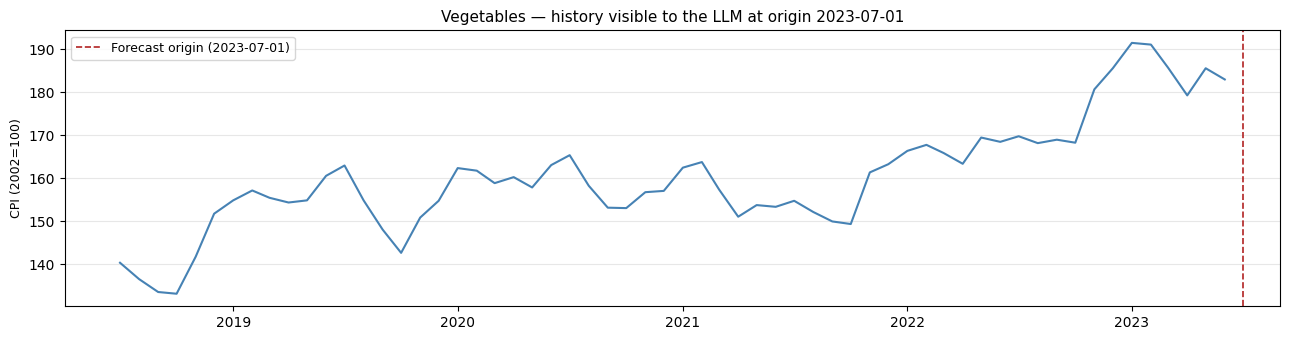

In [7]:
series_df, series_meta = get_history_and_meta(task, ctx)

if MAX_HISTORY_MONTHS is not None:
    series_df = series_df.tail(MAX_HISTORY_MONTHS)

history_str = serialize_history(series_df, precision=PRECISION)

print(f"History window : {series_df['timestamp'].iloc[0].strftime('%Y-%m')} "
      f"→ {series_df['timestamp'].iloc[-1].strftime('%Y-%m')}  "
      f"({len(series_df)} observations)")
if series_meta is not None:
    print(f"Description    : {series_meta.description}")
    print(f"Units          : {series_meta.units}")
    print(f"Source         : {series_meta.source}")

# Plot the history
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(pd.to_datetime(series_df["timestamp"]), series_df["value"],
        color="steelblue", linewidth=1.5)
ax.axvline(pd.Timestamp(origin), color="firebrick", linewidth=1.2,
           linestyle="--", label=f"Forecast origin ({origin.date()})")
label = CATEGORY_LABELS.get(task.target_series_id, task.target_series_id)
ax.set_title(f"{label} — history visible to the LLM at origin {origin.date()}", fontsize=11)
ax.set_ylabel("CPI (2002=100)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 5. The exact prompts

These are built by the same module-level functions the predictor uses.
What you see here is **verbatim what gets sent** to the LLM.

In [8]:
offset = pd.tseries.frequencies.to_offset(task.frequency)
n_steps = task.horizon
forecast_start = (pd.Timestamp(origin) + offset * 1).normalize()
forecast_end   = (pd.Timestamp(origin) + offset * n_steps).normalize()

system_prompt = _build_system_prompt()
user_prompt   = _build_user_prompt(
    task, history_str, series_meta,
    forecast_start, forecast_end, n_steps,
)

sep = "─" * 70
print(sep)
print("SYSTEM PROMPT")
print(sep)
print(system_prompt)

print()
print(sep)
print("USER PROMPT")
print(sep)
print(user_prompt)

print()
print(sep)
print("RESPONSE SCHEMA (json_schema response_format)")
print(sep)
print(json.dumps(_TRAJECTORY_JSON_SCHEMA, indent=2))

print()
print(f"Approximate prompt length : {len(system_prompt) + len(user_prompt):,} characters")

──────────────────────────────────────────────────────────────────────
SYSTEM PROMPT
──────────────────────────────────────────────────────────────────────
You are a probabilistic time-series forecaster. Given a historical series and a task description, return a single numerical trajectory covering the requested forecast window.

Rules:
- Return ONLY a JSON object matching the provided schema. No prose, no markdown, no chain-of-thought reasoning.
- The 'values' array MUST have exactly the requested number of elements, one per forecast step in chronological order.
- Use the same units and the same number of decimal places as the input series.
- Account for trend and seasonality implicitly. Do not emit reasoning tokens.
- Respect any constraints stated in the task description (non-negativity, domain bounds, known future events).

──────────────────────────────────────────────────────────────────────
USER PROMPT
──────────────────────────────────────────────────────────────────────
Task: 

---
## 6. Raw LLM calls — capture request and response

We call `litellm.completion` directly (bypassing the predictor) so we can
store the raw response string in a variable before any parsing happens.  We
make `N_SAMPLES` sequential calls here to mirror what the predictor does in
parallel.

Each call gets a small per-sample disambiguator appended to the user message
(the same trick the predictor uses to prevent LiteLLM's disk cache from
collapsing all draws into one response).

In [9]:
from aieng.forecasting.methods.llm_processes._client import (
    bootstrap_litellm,
    make_json_schema_response_format,
)

bootstrap_litellm()

response_format = make_json_schema_response_format("Trajectory", _TRAJECTORY_JSON_SCHEMA)

raw_responses: list[str] = []
usage_records: list[dict] = []

for i in range(N_SAMPLES):
    messages = [
        {"role": "system", "content": system_prompt},
        # The trailing comment makes each draw a distinct cache key.
        {"role": "user",   "content": user_prompt + f"\n# draw={i}"},
    ]
    resp = litellm.completion(
        model=MODEL,
        messages=messages,
        response_format=response_format,
        temperature=1.0,
        max_tokens=4096,
        timeout=120,
        reasoning_effort="disable",
    )
    raw_content = resp.choices[0].message.content
    raw_responses.append(raw_content)
    usage = getattr(resp, "usage", None)
    usage_records.append({
        "draw": i,
        "input_tokens":  getattr(usage, "prompt_tokens",     0) if usage else 0,
        "output_tokens": getattr(usage, "completion_tokens", 0) if usage else 0,
        "cost_usd":      float(getattr(resp, "_hidden_params", {}).get("response_cost") or 0.0),
    })
    print(f"Draw {i}  →  {len(raw_content)} chars  "
          f"(in={usage_records[-1]['input_tokens']} / "
          f"out={usage_records[-1]['output_tokens']} tokens  "
          f"~${usage_records[-1]['cost_usd']:.5f})")

total_cost = sum(r["cost_usd"] for r in usage_records)
print(f"\nTotal cost for {N_SAMPLES} draws: ~${total_cost:.5f}")

16:35:31 - LiteLLM:WARNING: opentelemetry.py:211 - Proxy Server is not installed. Skipping OpenTelemetry initialization.


Draw 0  →  114 chars  (in=1218 / out=106 tokens  ~$0.00093)
Draw 1  →  131 chars  (in=1218 / out=122 tokens  ~$0.00097)
Draw 2  →  114 chars  (in=1218 / out=106 tokens  ~$0.00093)

Total cost for 3 draws: ~$0.00283


---
## 7. Raw responses — what the LLM returned

The model returns a JSON object matching the schema above.  This is the
unmodified string before any parsing.

In [10]:
sep = "─" * 70
for i, raw in enumerate(raw_responses):
    print(f"{sep}\nDraw {i} — raw response\n{sep}")
    # Pretty-print if valid JSON, else show raw.
    try:
        print(json.dumps(json.loads(raw), indent=2))
    except json.JSONDecodeError:
        print(f"[PARSE FAILURE — raw content below]\n{raw}")
    print()

──────────────────────────────────────────────────────────────────────
Draw 0 — raw response
──────────────────────────────────────────────────────────────────────
{
  "values": [
    179.4,
    175.2,
    172.8,
    181.5,
    183.9,
    189.6,
    192.2,
    190.4,
    186.8,
    188.1,
    185.5,
    187.2,
    183.4,
    181.2,
    180.8,
    190.2,
    192.5
  ]
}

──────────────────────────────────────────────────────────────────────
Draw 1 — raw response
──────────────────────────────────────────────────────────────────────
{
  "values": [
    181.4,
    175.2,
    172.1,
    181.8,
    186.4,
    192.5,
    193.1,
    188.4,
    184.2,
    186.5,
    185.8,
    188.1,
    180.3,
    176.4,
    177.5,
    187.3,
    191.2
  ]
}

──────────────────────────────────────────────────────────────────────
Draw 2 — raw response
──────────────────────────────────────────────────────────────────────
{
  "values": [
    179.6,
    174.8,
    171.2,
    183.1,
    188.4,
    196.2,
    196.

---
## 8. Parsed trajectories — plot the samples

Each response is a list of `n_steps` values — one per forecast month.  We plot
every draw plus the actual observed values where available.

3 / 3 trajectories parsed successfully


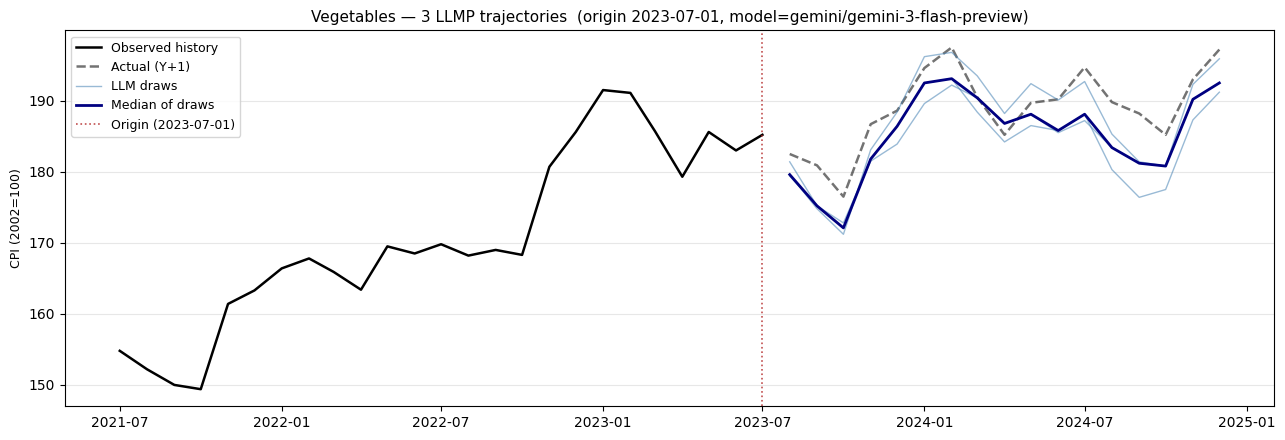

In [11]:
import numpy as np
from datetime import datetime, timezone

# Parse trajectories
trajectories: list[list[float]] = []
for i, raw in enumerate(raw_responses):
    try:
        parsed = json.loads(raw)
        vals = parsed["values"]
        if len(vals) != n_steps:
            print(f"Draw {i}: wrong length ({len(vals)} ≠ {n_steps}), skipping")
        else:
            trajectories.append(vals)
    except (json.JSONDecodeError, KeyError) as e:
        print(f"Draw {i}: parse error ({e}), skipping")

print(f"{len(trajectories)} / {N_SAMPLES} trajectories parsed successfully")

# Forecast dates
forecast_dates = pd.date_range(start=forecast_start, periods=n_steps, freq=task.frequency)

# Fetch actuals for comparison (using today's full data)
as_of_now = datetime.now(tz=timezone.utc).replace(tzinfo=None)
actual_df = svc.get_series(task.target_series_id, as_of=as_of_now)
actual_df["timestamp"] = pd.to_datetime(actual_df["timestamp"])
actuals_in_window = actual_df[
    (actual_df["timestamp"] >= forecast_start) &
    (actual_df["timestamp"] <= forecast_end)
]

# Observed history near the origin (last 24 months)
hist_start = pd.Timestamp(origin) - pd.DateOffset(months=24)
hist_window = actual_df[
    (actual_df["timestamp"] >= hist_start) &
    (actual_df["timestamp"] <= pd.Timestamp(origin))
]

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(hist_window["timestamp"], hist_window["value"],
        color="k", linewidth=1.8, label="Observed history")

if not actuals_in_window.empty:
    ax.plot(actuals_in_window["timestamp"], actuals_in_window["value"],
            color="k", linewidth=1.8, linestyle="--",
            alpha=0.55, label="Actual (Y+1)")

for i, traj in enumerate(trajectories):
    ax.plot(forecast_dates, traj, color="steelblue", linewidth=1.0,
            alpha=0.55, label=("LLM draws" if i == 0 else None))

if trajectories:
    arr = np.array(trajectories)
    ax.plot(forecast_dates, np.median(arr, axis=0), color="navy",
            linewidth=2.0, label="Median of draws")

ax.axvline(pd.Timestamp(origin), color="firebrick", linewidth=1.2,
           linestyle=":", alpha=0.8, label=f"Origin ({origin.date()})")

label = CATEGORY_LABELS.get(task.target_series_id, task.target_series_id)
ax.set_title(
    f"{label} — {N_SAMPLES} LLMP trajectories  "
    f"(origin {origin.date()}, model={MODEL})",
    fontsize=11,
)
ax.set_ylabel("CPI (2002=100)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 9. Full predictor path — `Prediction` objects with quantiles

This replicates exactly how the predictor runs during a backtest: it fans out
`N_SAMPLES` parallel calls, stacks the trajectories, and computes per-step
empirical quantiles.  The result is a list of `Prediction` objects, one per
horizon month.

In [12]:
predictor = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model=MODEL, n_samples=N_SAMPLES, precision=PRECISION)
)

predictions = predictor.predict(task, ctx)

print(f"Returned {len(predictions)} Prediction objects (one per horizon step)")
print(f"Predictor id : {predictor.predictor_id}")
print(f"Cost metadata from first prediction:")
meta = predictions[0].metadata
print(f"  model          = {meta.get('model')}")
print(f"  n_samples      = {meta.get('n_samples')}")
print(f"  input_tokens   = {meta.get('input_tokens')}")
print(f"  output_tokens  = {meta.get('output_tokens')}")
print(f"  cost_usd       = ${meta.get('cost_usd', 0):.5f}")
if meta.get('langfuse_trace_url'):
    print(f"  langfuse       = {meta['langfuse_trace_url']}")

Returned 12 Prediction objects (one per horizon step)
Predictor id : llmp_continuous[gemini/gemini-3-flash-preview]
Cost metadata from first prediction:
  model          = gemini/gemini-3-flash-preview
  n_samples      = 3
  input_tokens   = 25563
  output_tokens  = 334
  cost_usd       = $0.01378
  langfuse       = https://us.cloud.langfuse.com/project/cmobssx3g00buad07gb4o1gh6/traces/1e1153c928dd111150bc1a13daa7d9b2


In [13]:
# Tabulate the quantile forecast for each horizon step
rows = []
for pred in predictions:
    fd = pd.Timestamp(pred.forecast_date)
    q = pred.payload.quantiles
    rows.append({
        "forecast_month": fd.strftime("%Y-%m"),
        "q05":    round(q[0.05], 2),
        "q20":    round(q[0.20], 2),
        "median": round(pred.payload.point_forecast, 2),
        "q80":    round(q[0.80], 2),
        "q95":    round(q[0.95], 2),
    })
    actual_row = actual_df[actual_df["timestamp"] == fd]
    rows[-1]["actual"] = round(float(actual_row["value"].iloc[0]), 2) if not actual_row.empty else None

quant_df = pd.DataFrame(rows).set_index("forecast_month")
print(quant_df.to_string())

                   q05     q20  median     q80     q95  actual
forecast_month                                                
2024-01         192.68  193.52   195.2  195.98  196.37   194.6
2024-02         193.43  194.42   196.4  197.48  198.02   197.5
2024-03         188.94  189.66   191.1  193.32  194.43   190.5
2024-04         184.36  184.84   185.8  188.02  189.13   185.2
2024-05         187.68  188.22   189.3  191.58  192.72   189.7
2024-06         187.08  187.62   188.7  190.32  191.13   190.2
2024-07         188.61  189.24   190.5  191.76  192.39   194.7
2024-08         184.23  184.62   185.4  186.48  187.02   189.8
2024-09         179.60  179.60   179.6  181.10  181.85   188.2
2024-10         177.58  178.42   180.1  180.52  180.73   185.2
2024-11         187.35  188.70   191.4  193.26  194.19   193.0
2024-12         191.76  193.44   196.8  199.44  200.76   197.2


---
## 10. Things to try

Go back to **Section 2** and change the knobs:

- **Different `TASK_ID`** — compare how the model talks about vegetables vs.
  bakery/cereal vs. restaurants.
- **Different `ORIGIN_DATE`** — run a 2021-07-01 origin to see whether the
  model anticipated the 2022 food-price surge (hint: probably not).
- **`MAX_HISTORY_MONTHS = 36`** — trim the prompt to 3 years of history and
  compare against the full-history version.
- **`N_SAMPLES = 10`** — increase the sample count to see how wide the
  trajectory fan is and how stable the median is.
- **Different `MODEL`** — swap in `anthropic/claude-sonnet-4-5` or
  `gemini/gemini-3-flash-preview` and compare trajectories side-by-side.
- **`PRECISION = 0`** — round history to integers to see if that changes
  the model's behaviour (reduces prompt length too).